# Model Evaluation
Now that the model is trained, we must thoroughly evaluate it before we can move on to Phase 2. We will analyze the training history to check for overfitting, and then test the model against the unseen test dataset to generate a Classification Report and a Confusion Matrix.


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
import os

device = torch.device('cpu')

## 1. Training Visualization
Let's plot the Training vs Validation Loss, and Training vs Validation Accuracy over the epochs.


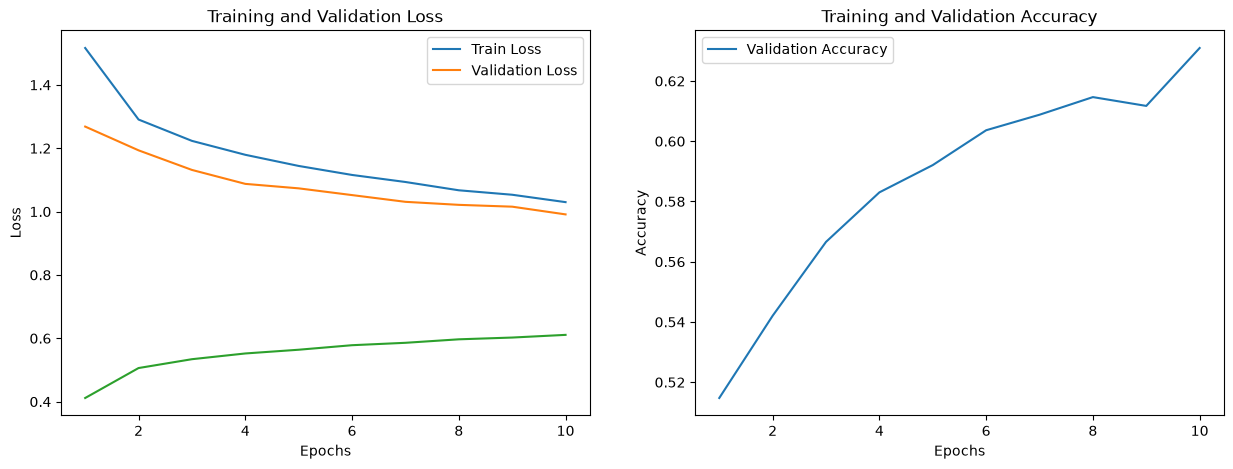

In [2]:
history_path = Path('../models/training_history.pkl')
if history_path.exists():
    with open(history_path, 'rb') as f:
        history = pickle.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss Plot
    ax1.plot(epochs, history['train_loss'], label='Train Loss')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Accuracy Plot
    ax1.plot(epochs, history['train_acc'], label='Train Accuracy')
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.savefig('../visualizations/training_history.png')
    plt.show()
else:
    print("Training history not found!")

## 2. Load the Best Model and Test Data
We must recreate the CNN architecture exactly as it was during training to load the saved weights. Then we load the `test` dataset.


In [3]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.block3(self.block2(self.block1(x))))

model = EmotionCNN(num_classes=7).to(device)
model.load_state_dict(torch.load('../models/best_emotion_cnn.pth', map_location=device))
model.eval()
print("Loaded best model weights.")

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = ImageFolder(root='../dataset/test', transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
class_names = test_dataset.classes

Loaded best model weights.


## 3. Generate Predictions
We run the model over the entire test dataset to collect the actual and predicted labels.


In [4]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Finished generating predictions on the test set.")

Finished generating predictions on the test set.


## 4. Classification Report & Confusion Matrix
Finally, we evaluate the performance using Precision, Recall, F1-Score, and a Confusion Matrix visualization.



--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.56      0.52      0.54       958
     disgust       0.50      0.44      0.47       111
        fear       0.48      0.33      0.39      1024
       happy       0.87      0.84      0.85      1774
     neutral       0.56      0.67      0.61      1233
         sad       0.48      0.57      0.52      1247
    surprise       0.77      0.75      0.76       831

    accuracy                           0.63      7178
   macro avg       0.60      0.59      0.59      7178
weighted avg       0.63      0.63      0.63      7178



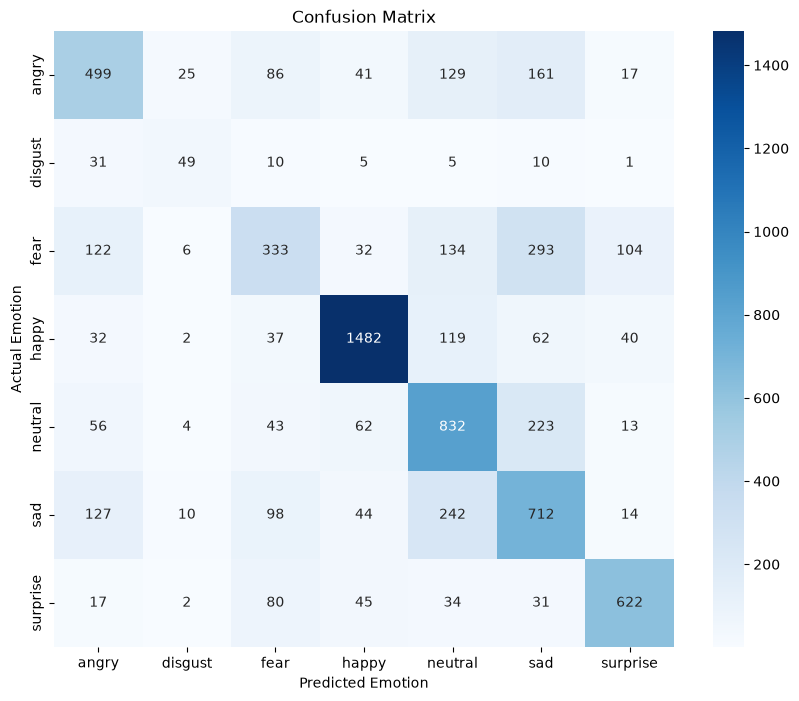

In [5]:
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.savefig('../visualizations/confusion_matrix.png')
plt.show()